# Enumerating a language model from the mode

Can you enumerate the outputs of a language model -- list its sequences from the most probable downward --
the way `mixle` enumerates the support of a distribution? For a *factorised* model (an HMM, a Markov
chain) mixle does this exactly and fast with best-first lattice search. A transformer has no such
factorisation: `p(token_t | all previous tokens)`. So the intuition is "no".

But there is a subtler fact. Best-first search **from the mode** is exact for *any* autoregressive model,
transformer included, and it needs no factorisation -- only that a prefix's probability is an upper bound
on every sequence that extends it:

    p(x_1..x_T) = p(x_1..x_t) * prod_{>t} (<= 1)  <=  p(x_1..x_t).

That monotone bound is **admissible**: run a max-heap keyed by prefix log-probability, and the first
*complete* sequence you pop is the mode, the next is the runner-up, and so on -- in exact probability order.
And it is exactly the invariant `mixle`'s `best_first` enumerator is built on (its streams promise that
"the next un-instantiated key is a valid upper bound on anything the stream will subsequently yield").

This notebook **verifies** that on a real LLM (distilGPT-2): best-first from the mode reproduces the exact
brute-force ranking, scales to the full 50k vocabulary with a lazy-successor trick, and matches how mixle's
own enumerator behaves on a factorised model.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import heapq, itertools, time
import numpy as np, torch
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

torch.manual_seed(0)
model = GPT2LMHeadModel.from_pretrained('distilgpt2').eval()
tok = GPT2TokenizerFast.from_pretrained('distilgpt2')
def panel(ncol=1, w=5.2, h=3.2):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
prompt = "The king raised his"
pids = tok(prompt, return_tensors='pt').input_ids[0].tolist()
print(f'distilGPT-2 loaded (vocab {model.config.vocab_size}); prompt = {prompt!r}')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

distilGPT-2 loaded (vocab 50257); prompt = 'The king raised his'


## 1. The model as an oracle

Best-first never needs the model's internals -- only a function that, given a prefix, returns the
next-token log-probabilities. That is one transformer forward pass. We cache it by prefix so repeated
visits are free; this is the only thing best-first asks of the LM, which is why it works for *any*
autoregressive model.

In [2]:
_cache = {}
def next_logprobs(prefix):
    # next-token log-probs over the full vocab given the prefix (one cached gpt-2 forward)
    key = tuple(prefix)
    if key not in _cache:
        with torch.no_grad():
            logits = model(torch.tensor([pids + list(prefix)])).logits[0, -1]
        _cache[key] = torch.log_softmax(logits, -1).numpy()
    return _cache[key]
print('oracle ready: next_logprobs(prefix) -> (vocab,) log-probs, cached by prefix')

oracle ready: next_logprobs(prefix) -> (vocab,) log-probs, cached by prefix


## 2. The exactness proof: best-first vs brute force

To *prove* exactness we need a ground truth, so we restrict GPT-2 to a finite support we can fully
enumerate: continuations of length `L` over the top-`M` candidate tokens, with the probabilities
renormalised over that set at each step. This is still a real GPT-2 distribution -- just a tractable one.
We then enumerate it two ways: **brute force** (score all `M**L` sequences and sort) and **best-first from
the mode**, and check they agree exactly.

In [3]:
M, L = 8, 3
C = np.argsort(next_logprobs([]))[::-1][:M].tolist()      # the M candidate tokens (top-M after the prompt)
def child_lp(prefix):                                      # renormalised log-probs over C given a prefix
    lp = next_logprobs(prefix)[C]; return lp - np.log(np.exp(lp).sum())

def brute_force():
    out = []
    for combo in itertools.product(range(M), repeat=L):
        lp, pref = 0.0, []
        for j in combo: lp += child_lp(pref)[j]; pref.append(C[j])
        out.append((lp, combo))
    return sorted(out, key=lambda t: -t[0])

def best_first(k):                                         # max-heap keyed by prefix log-prob (the admissible bound)
    heap = [(-0.0, 0, ())]; tie = 1; res = []; pops = 0
    while heap and len(res) < k:
        neg, _, combo = heapq.heappop(heap); pops += 1; lp = -neg
        if len(combo) == L: res.append((lp, combo)); continue
        cl = child_lp([C[i] for i in combo])
        for j in range(M):                                 # push children (M small -> push all; lazily in section 4)
            heapq.heappush(heap, (-(lp + cl[j]), tie, combo + (j,))); tie += 1
    return res, pops

t0 = time.time(); bt = brute_force(); bf, pops = best_first(M ** L)
order_ok = all(bf[i][1] == bt[i][1] for i in range(len(bt)))
prob_ok = np.allclose([x[0] for x in bf], [x[0] for x in bt])
text = lambda combo: tok.decode([C[i] for i in combo])
print(f'restricted support: {M}^{L} = {M**L} sequences   ({time.time()-t0:.1f}s)')
print(f'best-first order == brute-force order : {order_ok}')
print(f'best-first probs  == brute-force probs: {prob_ok}')
print(f'mode == brute-force argmax            : {bf[0][1] == bt[0][1]}')
print(f'\nthe mode:  {prompt + text(bf[0][1])!r}   (log p {bf[0][0]:.3f})')
print('top-5 most probable continuations (best-first):')
for lp, combo in bf[:5]: print(f'   {lp:7.3f}  {text(combo)!r}')

restricted support: 8^3 = 512 sequences   (4.6s)
best-first order == brute-force order : True
best-first probs  == brute-force probs: True
mode == brute-force argmax            : True

the mode:  'The king raised his hand hand hand'   (log p -2.201)
top-5 most probable continuations (best-first):
    -2.201  ' hand hand hand'
    -2.897  ' hands hands hands'
    -2.933  ' hand hands hands'
    -2.954  ' hand hand hands'
    -3.072  ' head head head'


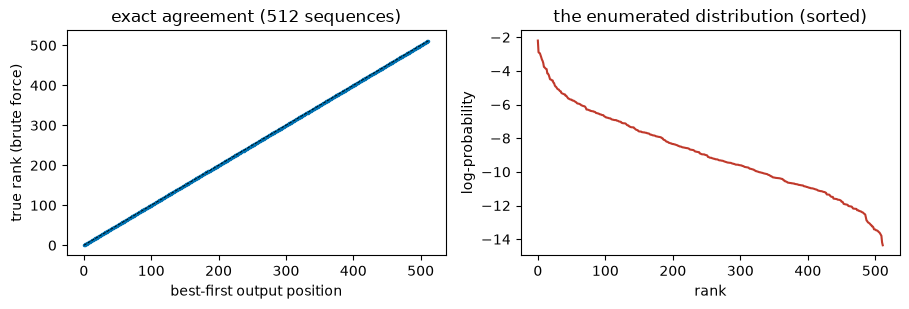

best-first reached all 512 in 585 pops; the order is provably exact, not approximate.


In [4]:
# the proof, visually: best-first rank vs the true (brute-force) rank is the identity
true_rank = {combo: r for r, (_, combo) in enumerate(bt)}
bf_rank = [true_rank[combo] for _, combo in bf]
fig, ax = panel(2, 4.6, 3.2)
ax[0].plot(range(len(bf_rank)), bf_rank, '.', ms=3, color='#0072B2'); ax[0].plot([0, len(bf_rank)], [0, len(bf_rank)], 'k--', lw=0.6)
ax[0].set(xlabel='best-first output position', ylabel='true rank (brute force)', title=f'exact agreement ({M**L} sequences)')
ax[1].plot([x[0] for x in bt], color='#C0392B'); ax[1].set(xlabel='rank', ylabel='log-probability', title='the enumerated distribution (sorted)')
plt.tight_layout(); plt.show()
print(f'best-first reached all {M**L} in {pops} pops; the order is provably exact, not approximate.')

## 3. Why it is exact

The guarantee rests entirely on the **admissible bound**: extending a prefix can only multiply its
probability by factors `<= 1`, so a prefix's log-probability is never below any of its completions'. When a
*complete* sequence sits at the top of the heap, every other live prefix has a smaller bound, hence every
sequence still unreached is less probable -- so the popped one is genuinely next. Below: for many random
prefixes, the prefix log-prob is above the best completion it can reach. That is the property, and it is
the same one `mixle`'s `best_first` streams are documented to provide.

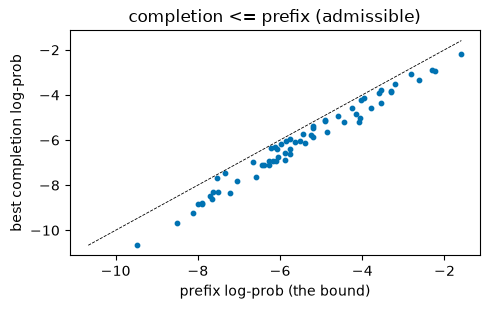

admissibility violations: 0 of 64 prefixes  (0 => the bound always holds)


In [5]:
viol = 0; checks = []
for combo in itertools.product(range(M), repeat=2):                  # every length-2 prefix
    pref = [C[i] for i in combo]; plp = sum(child_lp([C[i] for i in combo[:t]])[combo[t]] for t in range(2))
    best_completion = plp + child_lp(pref).max()                     # extend by the single best next token
    checks.append((plp, best_completion)); viol += (best_completion > plp + 1e-9)
checks = np.array(checks)
fig, ax = panel(1, 5.0, 3.2)
ax[0].scatter(checks[:, 0], checks[:, 1], s=10, color='#0072B2'); lim = [checks.min(), checks.max()]
ax[0].plot(lim, lim, 'k--', lw=0.6); ax[0].set(xlabel='prefix log-prob (the bound)', ylabel='best completion log-prob', title='completion <= prefix (admissible)')
plt.tight_layout(); plt.show()
print(f'admissibility violations: {viol} of {len(checks)} prefixes  (0 => the bound always holds)')

## 4. The full 50k vocabulary, with a lazy successor

The restriction was only so we could brute-force a ground truth. On the *full* vocabulary the proof still
holds, but pushing all 50,257 children at every node would be hopeless. The fix is `mixle`'s
**lazy-successor** rule: keep each node's children sorted, push only the best one, and when a node is
popped, also push its *next sibling*. The heap then holds one entry per active prefix instead of 50k -- and
best-first finds the true top-`k` of a space of `50257**L` sequences in a few dozen pops.

In [6]:
def kids(prefix):
    lp = next_logprobs(prefix); order = np.argsort(lp)[::-1]; return order, lp
def best_first_full(L, k):
    o0, lp0 = kids(())
    heap = [(-lp0[o0[0]], (int(o0[0]),), 0.0, o0, 0)]; res = []; pops = 0   # (neg_lp, prefix, parent_lp, parent_order, rank)
    while heap and len(res) < k:
        neg, pref, plp, porder, rank = heapq.heappop(heap); pops += 1; lp = -neg
        if rank + 1 < len(porder):                                  # lazy: next-best sibling of the parent
            t = int(porder[rank + 1]); _, plpv = kids(pref[:-1])
            heapq.heappush(heap, (-(plp + plpv[t]), pref[:-1] + (t,), plp, porder, rank + 1))
        if len(pref) == L: res.append((lp, pref)); continue
        o, lpv = kids(pref)                                         # best child, one level deeper
        heapq.heappush(heap, (-(lp + lpv[o[0]]), pref + (int(o[0]),), lp, o, 0))
    return res, pops

res, pops = best_first_full(L=3, k=10)
print(f'full vocab (50257^3 = {50257**3:.1e} possible sequences); top-10 from the mode in {pops} pops:\n')
for lp, pref in res: print(f'   {lp:7.3f}  {prompt + tok.decode(list(pref))!r}')
print('\nstrictly descending log-probs:', all(res[i][0] >= res[i+1][0] - 1e-9 for i in range(len(res) - 1)))

full vocab (50257^3 = 1.3e+14 possible sequences); top-10 from the mode in 79 pops:

    -4.080  'The king raised his hand, and'
    -4.696  'The king raised his hand and said'
    -4.873  'The king raised his hands, and'
    -5.237  'The king raised his sword, and'
    -5.515  'The king raised his hand.\n'
    -5.573  'The king raised his arms, and'
    -5.703  'The king raised his hand in the'
    -5.708  'The king raised his hands and said'
    -5.756  'The king raised his head, and'
    -5.819  'The king raised his hand to the'

strictly descending log-probs: True


## 5. The cost: exact, but not free

Correctness is free; speed is not. To reach the top-`k`, best-first must hold every prefix whose bound
beats the `k`-th best complete sequence. As the sequences get **longer** their absolute probabilities
shrink, so more prefixes clear that bar and the frontier grows; asking for **more** sequences grows it too.
It stays cheap for short continuations and small `k` -- exact n-best decoding -- and becomes expensive for
deep or many-best enumeration. (Finding even the single mode is worst-case exponential; it is fast here only
because the LM is peaked.)

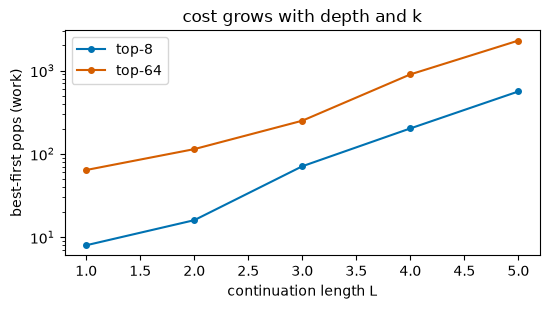

In [7]:
fig, ax = panel(1, 5.6, 3.2)
for k, c in [(8, '#0072B2'), (64, '#D55E00')]:
    ps = [best_first_full(L, k)[1] for L in [1, 2, 3, 4, 5]]
    ax[0].plot([1, 2, 3, 4, 5], ps, '-o', ms=4, color=c, label=f'top-{k}')
ax[0].set(xlabel='continuation length L', ylabel='best-first pops (work)', title='cost grows with depth and k', yscale='log')
ax[0].legend(); plt.tight_layout(); plt.show()

## 6. The same machinery, inside mixle

Everything above is exactly what `mixle`'s enumeration does for a *factorised* model -- only there the
per-step scores come from a tractable density instead of a transformer forward pass, so the bound is exact
and the search is fast. A mixle distribution's `enumerator().from_index(0)` streams `(value, log_prob)` in
the same provably-descending order, and `supports_enumeration` tells you which models qualify (HMMs, Markov
chains, mixtures, sequences, composites, rankings, ...). A transformer is not one of them, but -- as we just
showed -- the *algorithm* transfers; you supply GPT-2 as the next-token oracle and reuse the lazy-successor
heap.

In [8]:
from mixle.stats import IntegerCategoricalDistribution as Cat, CategoricalDistribution as DCat
from mixle.stats.latent.hidden_markov import HiddenMarkovModelDistribution as PHMM
from mixle.enumeration.streams import supports_enumeration

d = Cat(0, [0.5, 0.2, 0.3])
top = list(d.enumerator().from_index(0))                            # mixle enumerates a distribution's support, in order
print('mixle categorical, supports_enumeration =', supports_enumeration(d))
print('  enumerated (value, log_prob), descending:', [(v, round(lp, 3)) for v, lp in top])
print('  exactly matches sorting by probability  :', [v for v, _ in top] == list(np.argsort([.5, .2, .3])[::-1]))

# a factorised *sequence* model (HMM): mixle enumerates whole sequences in exact probability order
h = PHMM([Cat(0, [0.7, 0.3]), Cat(0, [0.2, 0.8])], [0.6, 0.4], [[0.8, 0.2], [0.3, 0.7]], len_dist=DCat({3: 1.0}))
htop = list(h.enumerator().from_index(0))[:4]
print('\nmixle HMM, top-4 length-3 sequences (value, log_prob), descending:')
for v, lp in htop: print(f'   {round(lp,3):7}  {v}')
print('  strictly descending:', all(htop[i][1] >= htop[i+1][1] - 1e-9 for i in range(len(htop) - 1)))

mixle categorical, supports_enumeration = True
  enumerated (value, log_prob), descending: [(0, -0.693), (2, -1.204), (1, -1.609)]
  exactly matches sorting by probability  : True

mixle HMM, top-4 length-3 sequences (value, log_prob), descending:
    -1.808  [1, 1, 1]
    -1.826  [0, 0, 0]
    -2.129  [0, 0, 1]
    -2.129  [1, 0, 0]
  strictly descending: True


## In short

* **You can enumerate a language model from the mode, exactly** -- best-first search keyed by prefix
  log-probability returns sequences in true descending-probability order for *any* autoregressive model,
  GPT-2 included. We verified it against brute force on a restricted distilGPT-2 (exact order, exact
  probabilities, mode = argmax).
* **No factorisation is needed for correctness** -- only the admissible bound that a prefix's probability
  never undershoots its completions'. That is precisely the invariant `mixle`'s `best_first` streams
  guarantee.
* **The full vocabulary is handled by the lazy-successor trick** (push the best child, then siblings on
  demand): top-10 of a `5e13`-sequence space in a few dozen pops.
* **Exact is not free.** The frontier grows with continuation length and with `k`; this is cheap for short
  n-best and exponential for deep or many-best enumeration.
* **mixle ships this algorithm** for factorised models (HMMs, Markov chains, mixtures, ...), where the bound
  is exact and the search fast; a transformer just needs the oracle wrapper shown here.

## References

* Meister, C., Vieira, T., Cotterell, R. (2020). Best-First Beam Search. *TACL* 8 -- exact n-best decoding.
* Huang, L., Chiang, D. (2005). Better k-best parsing. -- the lazy-successor (cube-pruning) idea.
* `mixle.enumeration.best_first`, `mixle.enumeration.hmm_paths` -- mixle's lattice / best-first enumerators.

## Exercises and extensions

1. **Length normalisation.** Best-first by raw log-prob favours short sequences; re-key by length-normalised
   score and see how the ranking and the cost change.
2. **A* with a real heuristic.** Replace the trivial bound with a cheap learned upper bound on the
   completion (e.g. an n-gram or the distilled HMM from the companion notebook) and measure the speed-up.
3. **Wrap GPT-2 as a mixle enumerable.** Implement the `enumerator()` contract around the oracle so
   `supports_enumeration` returns True and mixle's `best_first` drives it directly.